# Kinostatistiken in Österreich

In diesem Notebook werden unterschiedlichste Statistekn zum Thema Kino und Film in Österreich gezeigt und auf kreative Weise verglichen um neue Erkenntnise über das Thema zu liefern.

# Vorbereitungen

Bevor mit den Versuchen gestartet werden kann, müssen zuerste die jeweiligen Daten so wie entsprechende Python Libaries importiert werden, um die Menge an Daten bestmöglich zu verarbeiten und dar zu stellen.

## Import derr Libraries

Um die Datenmenge bestmöglich zu vearbeiten zu können, werden folgende Libraries importiert:

In [14]:
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/51.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/51.5 kB ? eta -:--:--
     ------- -------------------------------- 10.2/51.5 kB ? eta -:--:--
     --------------- ---------------------- 20.5/51.5 kB 165.2 kB/s eta 0:00:01
     --------------- ---------------------- 20.5/51.5 kB 165.2 kB/s eta 0:00:01
     ------------------------------ ------- 41.0/51.5 kB 196.9 kB/s eta 0:00:01
     -------------------------------------- 51.5/51.5 kB 220.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.2/1.1 MB 3.3 MB/s eta 0:00:01
   ------------ --------------------------- 0.3/1.1 MB 3.5 MB/s eta 0:00:01
   ------------------- -------------------- 0.6/1.1 MB 3.8 MB/s eta 0:00:01
   -------------------------- ------------- 0.7/1.1 MB 3.9 MB/s eta 0:00:01
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [15]:
#Import von Pandas
import pandas as pd
#Import von MongoDB Client
from pymongo import MongoClient
#Import von Seaborn
import seaborn as sns
#Import von Matplotlib
import matplotlib.pyplot as plt
#Import von NumPY
import numpy as np
#Import von Plotly.express
import plotly.express as px
import geopandas as gpd

Diese Bibliotheken sind wichtig für die Verarbeitung von Big Data, da sie effiziente Datenstrukturen, leistungsstarke Analysetools und skalierbare Visualisierungsmöglichkeiten bieten, um große Datenmengen zu handhaben und aussagekräftige Erkenntnisse zu gewinnen.

Eine kurze Erklärung, wofür die importierten Libraries notwendig sind:

Pandas: Wird verwendet, um Daten in tabellarischer Form zu organisieren und zu analysieren. Es bietet Datenstrukturen und Funktionen, um Daten effizient zu manipulieren und zu bearbeiten.

Seaborn: Eine Datenvisualisierungs-Bibliothek, die auf Matplotlib aufbaut und eine einfachere Syntax für die Erstellung ästhetisch ansprechender statistischer Grafiken bietet.

Matplotlib.pyplot: Eine umfassende Visualisierungsbibliothek für Python. Sie ermöglicht die Erstellung verschiedener Arten von Diagrammen, Plots und visuellen Darstellungen von Daten.

Numpy: Wird verwendet, um effiziente multidimensionale Array-Operationen durchzuführen, insbesondere für numerische Berechnungen und Datenverarbeitung in Python.

Plotly.express: Eine Bibliothek zur einfachen Erstellung interaktiver und ansprechender Visualisierungen. Plotly Express bietet eine hohe Abstraktionsebene und ermöglicht die schnelle Erstellung von Diagrammen und interaktiven Dashboards.

# Datenmanagement

Um Analysen der Statistien durchzuführen werden natürlich auch entsprechende Statistiken benötigt.

Damit die Arbeitsmappe mit pandas eingelesen werden kann, muss diese zuerst in Excel von einer OpenDocument Spreadsheet-Datei (ODS) in eine Excel Arbeitsmappe konvertiert werden.

In [1]:
!docker pull mongo

Using default tag: latest


What's Next?
  View a summary of image vulnerabilities and recommendations â†’ docker scout quickview mongo



latest: Pulling from library/mongo
e311a697a403: Pulling fs layer
96480145cf35: Pulling fs layer
9507583e18ac: Pulling fs layer
dcf50fa6e139: Pulling fs layer
2c7e77b05b66: Pulling fs layer
d41bdd4b0b5d: Pulling fs layer
8da96db6d2f6: Pulling fs layer
cdd61f5ba74e: Pulling fs layer
dcf50fa6e139: Waiting
2c7e77b05b66: Waiting
d41bdd4b0b5d: Waiting
8da96db6d2f6: Waiting
cdd61f5ba74e: Waiting
96480145cf35: Verifying Checksum
96480145cf35: Download complete
9507583e18ac: Verifying Checksum
9507583e18ac: Download complete
2c7e77b05b66: Verifying Checksum
2c7e77b05b66: Download complete
d41bdd4b0b5d: Verifying Checksum
d41bdd4b0b5d: Download complete
dcf50fa6e139: Verifying Checksum
dcf50fa6e139: Download complete
cdd61f5ba74e: Verifying Checksum
cdd61f5ba74e: Download complete
e311a697a403: Download complete
e311a697a403: Pull complete
96480145cf35: Pull complete
9507583e18ac: Pull complete
dcf50fa6e139: Pull complete
2c7e77b05b66: Pull complete
d41bdd4b0b5d: Pull complete
8da96db6d2f6: Ve

In [2]:
!docker run -d -p 27017:27017 --name mongodb mongo

91d327f5436e395b1edb06fe70bd9709e4aa0ad7cca5dfb74d758036184c4ad3


In [21]:
# Connect to MongoDB
client = MongoClient('localhost', 27017)  # Connect to the MongoDB container
db = client['cinema_db']  # Create or get the database

# Specify the Excel file path
excel_file = 'Kino_Filme_2019.xlsx'

# Load all sheets from the Excel file
excel_data = pd.read_excel(excel_file, sheet_name=None)

# Iterate through each sheet and upload data to MongoDB
for sheet_name, df in excel_data.items():
    # Remove rows with NaN values
    df = df.dropna()

    # Create a collection in the database for each sheet
    collection = db[sheet_name]

    # Convert the DataFrame to a list of dictionaries and insert into MongoDB
    data = df.to_dict('records')
    collection.insert_many(data)

print("Data uploaded to MongoDB")

Data uploaded to MongoDB


In [22]:
# Dictionary für die bereinigten DataFrames erstellen
cleaned_sheets_dict = {}

# Alle Tabellen in der Datenbank durchlaufen und bereinigen
for sheet_name in db.list_collection_names():
    # Zugriff auf die Sammlung in der Datenbank
    collection = db[sheet_name]

    # Daten aus der Sammlung abrufen und in ein DataFrame umwandeln
    data = list(collection.find())
    df = pd.DataFrame(data)

    # Bereinigen des DataFrames (Entfernen von Zeilen mit NaN-Werten)
    cleaned_df = df.dropna()

    # Speichern des bereinigten DataFrames im Dictionary
    cleaned_sheets_dict[sheet_name] = cleaned_df

# Zugriff auf die bereinigten DataFrames aus dem Dictionary
df_struktur = cleaned_sheets_dict['Tabelle_K1']
df_säle = cleaned_sheets_dict['Tabelle_K2']
df_plätze = cleaned_sheets_dict['Tabelle_K3']
df_besuche = cleaned_sheets_dict['Tabelle_K4']
df_nettoIn = cleaned_sheets_dict['Tabelle_K5']
df_erstAuf = cleaned_sheets_dict['Tabelle_K6']
df_marktTeil = cleaned_sheets_dict['Tabelle_K7']
df_erfolgInterNat = cleaned_sheets_dict['Tabelle_K8']
df_meistÖFilm = cleaned_sheets_dict['Tabelle_K9']

# Beispielhafte Anzeige der bereinigten Daten
print(df_plätze.head())

                        _id  \
0  66300c9bc749d912bf1f18dd   
1  66300c9bc749d912bf1f18de   
2  66300c9bc749d912bf1f18df   
3  66300c9bc749d912bf1f18e0   
4  66300c9bc749d912bf1f18e1   

  K3.  Sitzplatzkapazität der Kinos nach Bundesländern 1975 bis 2019  \
0                                              Jahr                    
1                                               1975                   
2                                               1980                   
3                                               1985                   
4                                               1990                   

      Unnamed: 1     Unnamed: 2 Unnamed: 3           Unnamed: 4  \
0  Öster-\nreich  Burgen-\nland    Kärnten  Nieder-\nösterreich   
1         179725          10950      13435                42025   
2         146230           8843      10301                33799   
3         128876           5274      10432                24068   
4          76986           2272       6172   

In [23]:
# Neue Spaltennamen definieren
neue_spaltennamen = {
    "Unnamed: 1": "Österreich",
    "Unnamed: 2": "Burgen-\nland",
    "Unnamed: 3": "Kärnten",
    "Unnamed: 4": "Nieder-\nösterreich",
    "Unnamed: 5": "Ober-\nösterreich",
    "Unnamed: 6": "Salzburg",
    "Unnamed: 7": "Steier-\nmark",
    "Unnamed: 8": "Tirol",
    "Unnamed: 9": "Vorarl-\nberg",
    "Unnamed: 10": "Wien"
}

# Umbenennen der Spalten in den notwendigen Datensätzen
df_säle = df_säle.rename(columns=neue_spaltennamen)
df_besuche = df_besuche.rename(columns=neue_spaltennamen)
df_struktur = df_struktur.rename(columns=neue_spaltennamen)
df_plätze = df_plätze.rename(columns=neue_spaltennamen)
df_nettoIn = df_nettoIn.rename(columns=neue_spaltennamen)

# Neuer Name für die spezifische Spalte
neuer_spaltenname = "Jahr"

# Umbenennen der spezifischen Spalte in df_plätze
df_säle = df_säle.rename(columns={"K2.  Kinosäle nach Bundesländern 1975 bis 2019": neuer_spaltenname})
df_besuche = df_besuche.rename(columns={"K4.  Kinobesuche nach Bundesländern 1975 bis 2019": neuer_spaltenname})
df_plätze = df_plätze.rename(columns={"K3.  Sitzplatzkapazität der Kinos nach Bundesländern 1975 bis 2019": neuer_spaltenname})
df_nettoIn = df_nettoIn.rename(columns={"K5.  Nettoeinnahmen der Kinos nach Bundesländern 1985 bis 2019": neuer_spaltenname})

# Neuer Name für die spezifische Spalte
neuer_spaltenname_gliederung = "Gliederung"
df_struktur = df_struktur.rename(columns={"K1.  Struktur der Kinos (Anzahl der Säle, Sitzplatzkapazität, Bespielung) 2019 nach Bundesländern": neuer_spaltenname_gliederung}) 
print(df_plätze.head())


                        _id   Jahr     Österreich  Burgen-\nland  Kärnten  \
0  66300c9bc749d912bf1f18dd  Jahr   Öster-\nreich  Burgen-\nland  Kärnten   
1  66300c9bc749d912bf1f18de   1975         179725          10950    13435   
2  66300c9bc749d912bf1f18df   1980         146230           8843    10301   
3  66300c9bc749d912bf1f18e0   1985         128876           5274    10432   
4  66300c9bc749d912bf1f18e1   1990          76986           2272     6172   

   Nieder-\nösterreich  Ober-\nösterreich  Salzburg  Steier-\nmark  Tirol  \
0  Nieder-\nösterreich  Ober-\nösterreich  Salzburg  Steier-\nmark  Tirol   
1                42025              29651     10656          24228  11802   
2                33799              25719      8504          19377  10334   
3                24068              24292      8654          19599   9094   
4                11779              12638      5910          10068   6786   

   Vorarl-\nberg   Wien  
0  Vorarl-\nberg   Wien  
1           5796  3118

Die einzelen Tabs der Arbeitsmappe wurden bereinigt (NaN Werte wurden entfernt), unter eigenen Variabeln gespeichert und können nun verwendet werden.

# Analyse

In [24]:
df_plätze= df_plätze.iloc[1:]  # Erste Zeile entfernen
df_säle= df_säle.iloc[1:]  # Erste Zeile entfernen
df_nettoIn= df_nettoIn.iloc[1:]
df_besuche= df_besuche.iloc[1:]
# Abfrage der Zeilennamen
zeilennamen = df_säle


# Ausgabe der Zeilennamen
print(df_plätze.head())

                        _id  Jahr Österreich Burgen-\nland Kärnten  \
1  66300c9bc749d912bf1f18de  1975     179725         10950   13435   
2  66300c9bc749d912bf1f18df  1980     146230          8843   10301   
3  66300c9bc749d912bf1f18e0  1985     128876          5274   10432   
4  66300c9bc749d912bf1f18e1  1990      76986          2272    6172   
5  66300c9bc749d912bf1f18e2  1995      72716          2304    5842   

  Nieder-\nösterreich Ober-\nösterreich Salzburg Steier-\nmark  Tirol  \
1               42025             29651    10656         24228  11802   
2               33799             25719     8504         19377  10334   
3               24068             24292     8654         19599   9094   
4               11779             12638     5910         10068   6786   
5               11955             13217     5021          8021   5615   

  Vorarl-\nberg   Wien  
1          5796  31182  
2          5160  24193  
3          5445  22018  
4          3608  17753  
5          2798

In [25]:
# Daten für die Sitzplatzkapazität und Anzahl der Kinosäle extrahieren
jahre_kapazität = df_plätze['Jahr'].tolist()
sitzplatzkapazität = df_plätze['Österreich'].tolist()

jahre_säle = df_säle['Jahr'].tolist()
kinosäle = df_säle['Anzahl_Kinosäle'].tolist()

# Zeitlicher Vergleich von Sitzplatzkapazität und Anzahl der Kinosäle
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot für Sitzplatzkapazität auf Achse 1
color = 'tab:blue'
ax1.set_xlabel('Jahr')
ax1.set_ylabel('Sitzplatzkapazität', color=color)
ax1.plot(jahre_kapazität, sitzplatzkapazität, color=color, label='Sitzplatzkapazität')
ax1.tick_params(axis='y', labelcolor=color)

# Zweite y-Achse für Anzahl der Kinosäle
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Anzahl Kinosäle', color=color)
ax2.plot(jahre_säle, kinosäle, color=color, label='Anzahl Kinosäle')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
fig.legend(loc="upper right")
plt.title('Zeitlicher Vergleich von Sitzplatzkapazität und Anzahl der Kinosäle')

# Setze die Anzeige der x-Ticks
tick_step = 2  # Schritte zwischen den angezeigten Ticks
plt.xticks(jahre_kapazität[::tick_step], rotation=45)  # Nur jeden `tick_step`-ten Eintrag anzeigen

plt.show()

# Angenommen, Sie haben bereits die richtigen Spalten für die Jahre extrahiert
jahre_säle = df_säle['Jahr']
jahre_kapazität = df_plätze['Jahr']

# Nehmen wir an, Sie haben die Anzahl der Kinosäle und Sitzplatzkapazität bereits in den Variablen kinosäle und sitzplatzkapazität gespeichert

# Erstellen eines neuen DataFrames mit den Jahren und den jeweiligen Daten
df_jahre = pd.DataFrame({'Jahr': jahre_kapazität, 'Anzahl_Säle': jahre_säle, 'Sitzplatzkapazität': sitzplatzkapazität})

# Heatmap der Sitzplatzkapazität nach Kategorien über die Jahre
heatmap_data = df_jahre.pivot(index='Jahr', columns='Anzahl_Säle', values='Sitzplatzkapazität')
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title('Verteilung von Sitzplatzkapazität nach Anzahl der Säle über die Jahre')
plt.show()

KeyError: 'Anzahl_Kinosäle'

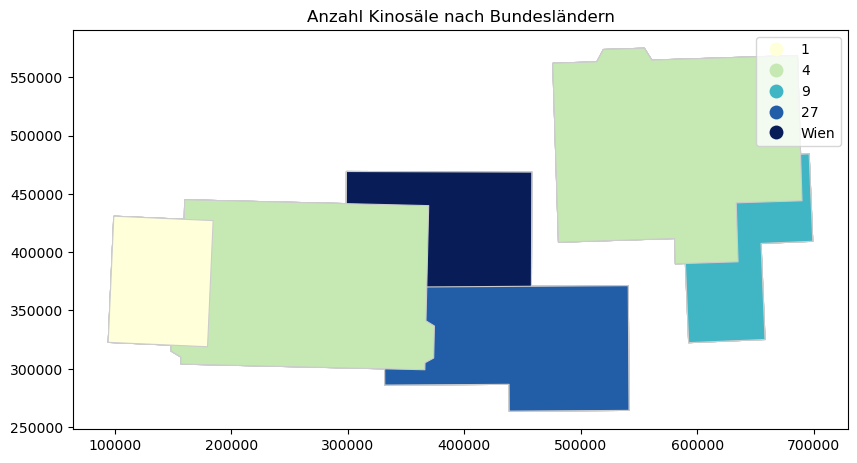

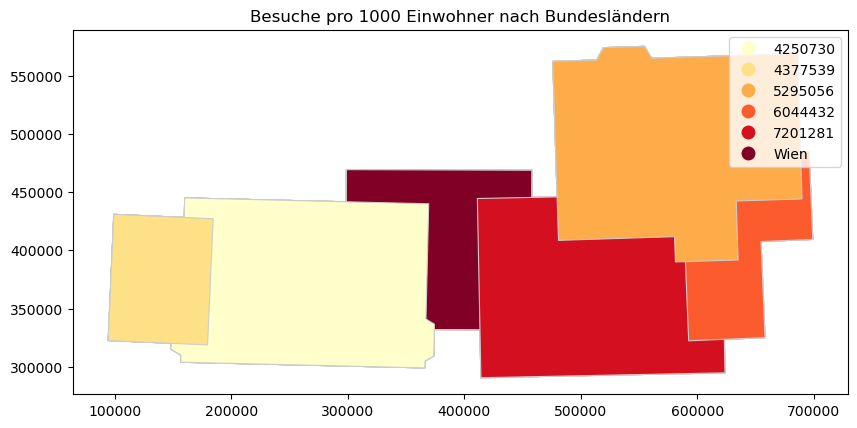

In [101]:
# Annahme: Die Bundesländer sind als Index im DataFrame df_struktur und gdf enthalten
df_struktur = cleaned_sheets_dict['Tabelle_K1']
df_besuche = cleaned_sheets_dict['Tabelle_K4']
gdf = gpd.read_file('BLK200_Lambert.shp')

# Füge Daten zu Geodaten hinzu (Merge anhand der Indexe)
merged_struktur = gdf.merge(df_struktur, how='left', left_index=True, right_index=True)
merged_besuche = gdf.merge(df_besuche, how='left', left_index=True, right_index=True)

# Filtere die erste Zeile aus der Spalte 'Unnamed: 1' im DataFrame merged
merged_struktur_filtered = merged_struktur.iloc[1:]
merged_besuche_filtered = merged_besuche.iloc[1:]

# Definiere die korrekten Spalten für die Anzahl der Kinosäle nach Bundesländern
bundesland_spalten = [
    'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 
    'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'
]

# Erstelle Kartenvisualisierung der Kinosäle nach Bundesländern
fig, ax = plt.subplots(figsize=(10, 10))
for spalte in bundesland_spalten:
    merged_struktur_filtered.plot(column=spalte, cmap='YlGnBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
plt.title('Anzahl Kinosäle nach Bundesländern')
plt.show()

# Choroplethenkarte der Besuchszahlen pro 1000 Einwohner
fig, ax = plt.subplots(figsize=(10, 10))
for spalte in bundesland_spalten:
    merged_besuche_filtered.plot(column=spalte, cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
plt.title('Besuche pro 1000 Einwohner nach Bundesländern')
plt.show()


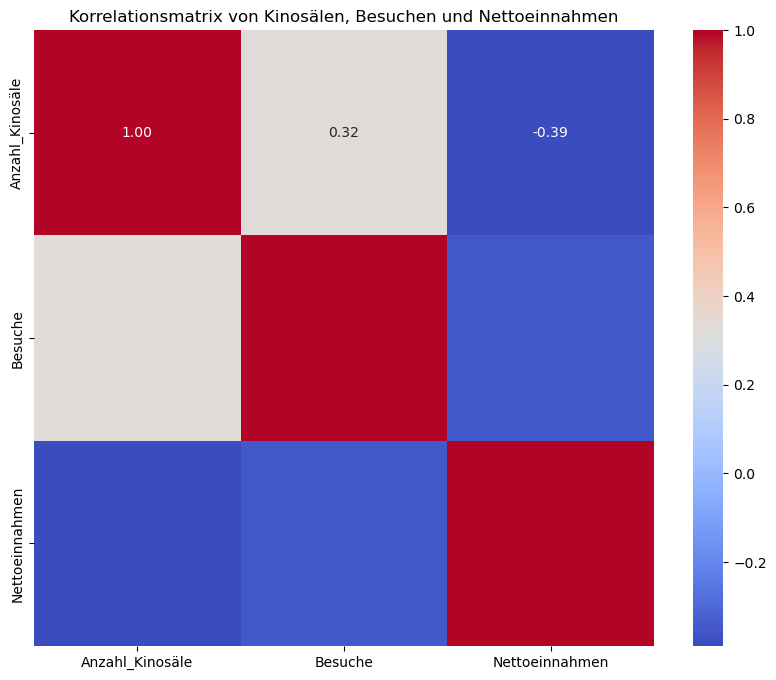

In [146]:
# Neue Spaltennamen definieren als Dictionaries
neue_spaltennamen_säle = {
    "Österreich": "Anzahl_Kinosäle"
}

neue_spaltennamen_besuche = {
    "Österreich": "Besuche"
}

neue_spaltennamen_netto = {
    "Österreich": "Nettoeinnahmen"
}

# Umbenennen der Spalten in den DataFrames
df_säle = df_säle.rename(columns=neue_spaltennamen_säle)
df_besuche = df_besuche.rename(columns=neue_spaltennamen_besuche)
df_nettoIn = df_nettoIn.rename(columns=neue_spaltennamen_netto)


# Merge Daten aus verschiedenen DataFrames basierend auf dem Jahr
merged_data = df_säle.merge(df_besuche, on='Jahr').merge(df_nettoIn, on='Jahr')

# Berechne Korrelationsmatrix
correlation_matrix = merged_data[['Anzahl_Kinosäle', 'Besuche', 'Nettoeinnahmen']].corr()

# Plot Heatmap der Korrelationsmatrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korrelationsmatrix von Kinosälen, Besuchen und Nettoeinnahmen')
plt.show()


C:\ProgramData\Anaconda3\naviagtor\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\Anaconda3\naviagtor\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


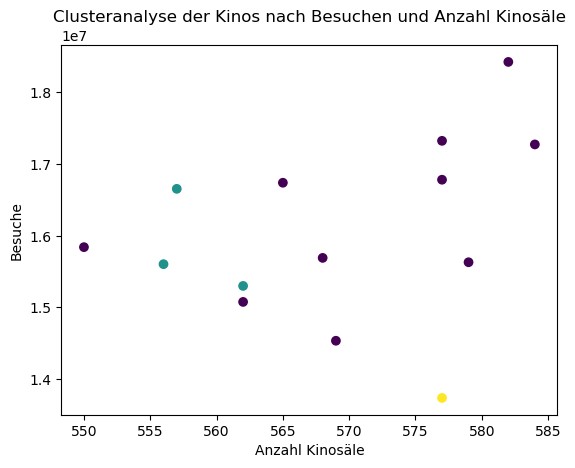

In [144]:
from sklearn.cluster import KMeans


# Daten für Clusteranalyse vorbereiten
X = merged_data[['Anzahl_Kinosäle', 'Besuche', 'Nettoeinnahmen']].values

# KMeans Clustering
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
merged_data['Cluster'] = kmeans.labels_

# Visualisierung der Cluster mit Scatterplot
plt.scatter(merged_data['Anzahl_Kinosäle'], merged_data['Besuche'], c=merged_data['Cluster'], cmap='viridis')
plt.xlabel('Anzahl Kinosäle')
plt.ylabel('Besuche')
plt.title('Clusteranalyse der Kinos nach Besuchen und Anzahl Kinosäle')
plt.show()

In [145]:
import plotly.express as px

# Erstelle interaktives Dashboard mit Plotly Express
fig = px.scatter(merged_data, x='Anzahl_Kinosäle', y='Besuche', color='Jahr', size='Nettoeinnahmen',
                 hover_data=['Bundesland'], title='Kino-Dashboard')
fig.show()

ValueError: Value of 'hover_data_0' is not the name of a column in 'data_frame'. Expected one of ['Jahr', 'Anzahl_Kinosäle', 'Burgen-\nland_x', 'Kärnten_x', 'Nieder-\nösterreich_x', 'Ober-\nösterreich_x', 'Salzburg_x', 'Steier-\nmark_x', 'Tirol_x', 'Vorarl-\nberg_x', 'Wien_x', 'Besuche', 'Burgen-\nland_y', 'Kärnten_y', 'Nieder-\nösterreich_y', 'Ober-\nösterreich_y', 'Salzburg_y', 'Steier-\nmark_y', 'Tirol_y', 'Vorarl-\nberg_y', 'Wien_y', 'Nettoeinnahmen', 'Burgen-\nland', 'Kärnten', 'Nieder-\nösterreich', 'Ober-\nösterreich', 'Salzburg', 'Steier-\nmark', 'Tirol', 'Vorarl-\nberg', 'Wien', 'Cluster'] but received: Bundesland